In [1]:
import numpy as np
from commpy.utilities  import upsample
from optic.models.devices import ring_modulator, photodiode
from optic.comm.modulation import modulateGray
from optic.dsp.core import pulseShape, lowPassFIR, pnorm, signal_power

try:
    from optic.dsp.coreGPU import firFilter
except ImportError:
    from optic.dsp.core import firFilter

from optic.utils import parameters, dBm2W
from optic.plot import eyediagram
import matplotlib.pyplot as plt
from scipy.special import erfc
from tqdm.notebook import tqdm
import scipy as sp

Average power of the modulated optical signal [mW]: 0.537 mW
Average power of the modulated optical signal [dBm]: -2.701 dBm


c:\anaconda\envs\OptiCommPy\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\anaconda\envs\OptiCommPy\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


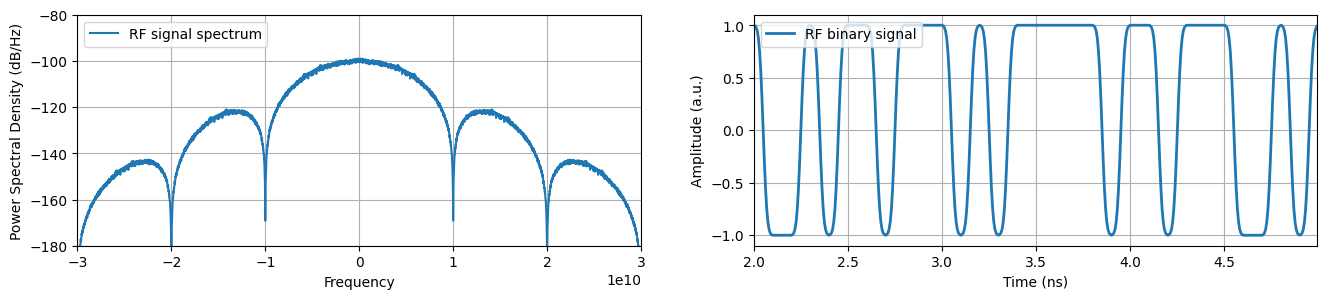

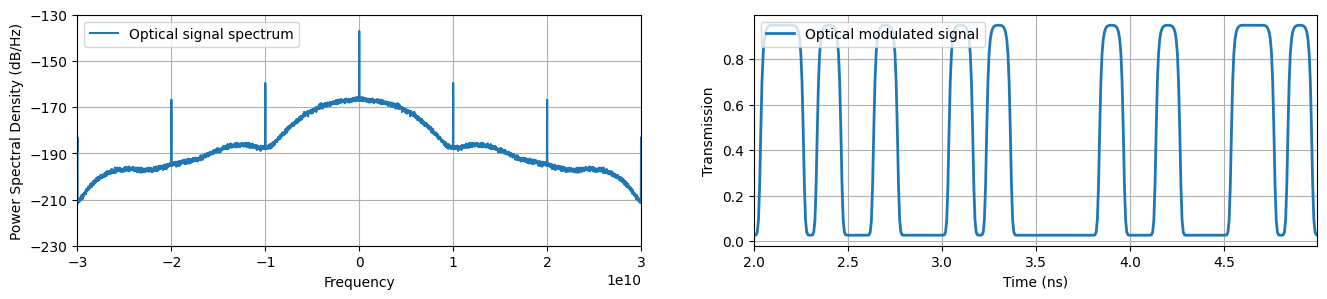

In [2]:
# simulation parameters
SpS = 16     # samples per symbol
M = 2        # order of the modulation format
Rs = 10e9    # Symbol rate (for OOK case Rs = Rb)
Fs = Rs*SpS  # Sampling frequency
Ts = 1/Fs    # Sampling period

# Laser power
Pi_dBm = 0         # laser optical power at the input of the MZM in dBm
Pi = dBm2W(Pi_dBm) # convert from dBm to W

# MZM parameters
paramRing = parameters()
paramRing.Ts                = Ts
paramRing.radius            = 10e-6 #10um radius
paramRing.ng                = 4.2  #Group index, typical value for silicon
paramRing.coupling          = 0.12 #Fraction of power coupled on bus coupler
paramRing.loss_rate         = 3000 #30dB/cm waveguide loss rate, reasonable for PN junction in silicon
paramRing.detuning          = -40e9 #Laser starts parked 40GHz off resonance with the ring
paramRing.EO_efficiency     = 40e9 #40 GHz / volt detuning efficiency

# generate pseudo-random bit sequence
bitsTx = np.random.randint(2, size=100000)

# generate 2-PAM modulated symbol sequence
symbTx = modulateGray(bitsTx, M, 'pam')    
symbTx = pnorm(symbTx) # power normalization

# upsampling
symbolsUp = upsample(symbTx, SpS)

# typical NRZ pulse
pulse = pulseShape('nrz', SpS)
pulse = pulse/max(abs(pulse))

# pulse shaping
sigTx = firFilter(pulse, symbolsUp)

# optical modulation
Ai = np.sqrt(Pi)
sigTxo = ring_modulator(Ai, sigTx, paramRing)

print('Average power of the modulated optical signal [mW]: %.3f mW'%(signal_power(sigTxo)/1e-3))
print('Average power of the modulated optical signal [dBm]: %.3f dBm'%(10*np.log10(signal_power(sigTxo)/1e-3)))

fig, axs = plt.subplots(1, 2, figsize=(16,3))
interval = np.arange(16*20,16*50)
t = interval*Ts/1e-9

# plot psd
axs[0].set_xlim(-3*Rs,3*Rs);
axs[0].set_ylim(-180,-80);
axs[0].psd(sigTx,Fs=Fs, NFFT = 16*1024, sides='twosided', label = 'RF signal spectrum')
axs[0].legend(loc='upper left');

axs[1].plot(t, sigTx[interval], label = 'RF binary signal', linewidth=2)
axs[1].set_ylabel('Amplitude (a.u.)')
axs[1].set_xlabel('Time (ns)')
axs[1].set_xlim(min(t),max(t))
axs[1].legend(loc='upper left')
axs[1].grid()

fig, axs = plt.subplots(1, 2, figsize=(16,3))
# plot psd
axs[0].set_xlim(-3*Rs,3*Rs);
axs[0].set_ylim(-230,-130);
axs[0].psd(np.abs(sigTxo)**2, Fs=Fs, NFFT = 16*1024, sides='twosided', label = 'Optical signal spectrum')
axs[0].legend(loc='upper left');

# axs[1].plot(t, np.real(sigTxo[interval]), label = 'Optical modulated signal', linewidth=2)
axs[1].plot(t, np.abs(sigTxo[interval])**2/Pi, label = 'Optical modulated signal', linewidth=2)
axs[1].set_ylabel('Transmission')
axs[1].set_xlabel('Time (ns)')
axs[1].set_xlim(min(t),max(t))
axs[1].legend(loc='upper left')
axs[1].grid()

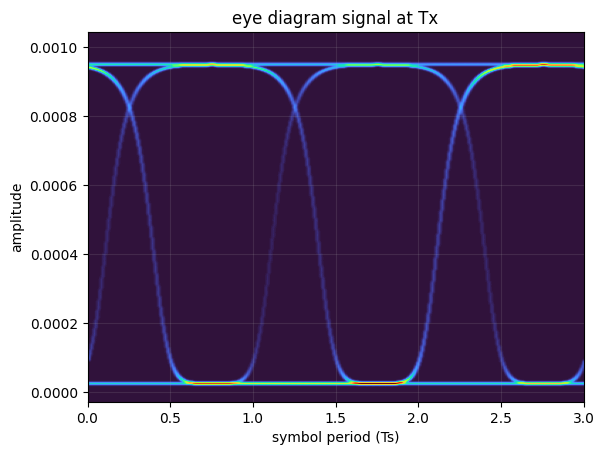

In [3]:
# ideal photodiode (noiseless, no bandwidth limitation)
paramPD = parameters()
paramPD.ideal = True
paramPD.Fs = Fs

I_Tx = photodiode(sigTxo, paramPD) # transmitted signal
discard = 100
eyediagram(I_Tx[discard:-discard], I_Tx.size-2*discard, SpS, plotlabel='signal at Tx', ptype='fancy')